CELL 3

prices_s: 
0.950607    14.0
0.961191    14.0
0.986001    93.0
0.986640    25.0
0.990505    21.0
dtype: float64


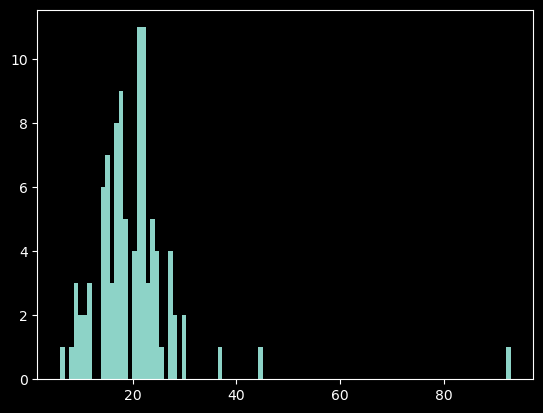

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

np.random.seed(42)
p = 20 + 5 * np.random.standard_t(5, size=100)
prices = np.round(p)
# print(f"Daily prices: {prices}")
plt.style.use("dark_background")
plt.hist(prices, 100)
prices_s = pd.Series(prices, index = np.random.rand(len(prices)))
prices_x = prices_s.sort_index()
# print(f"prices_df: \n{prices_df}")
# convert to log
# returns = prices_s/prices_s.shift(1)
# log_returns = np.log(prices_df/prices_df.shift(1))
print(f"prices_s: \n{prices_x.tail(5)}")
# plt.plot(prices_df)
# get Standard deviation  of prices


CELL 4

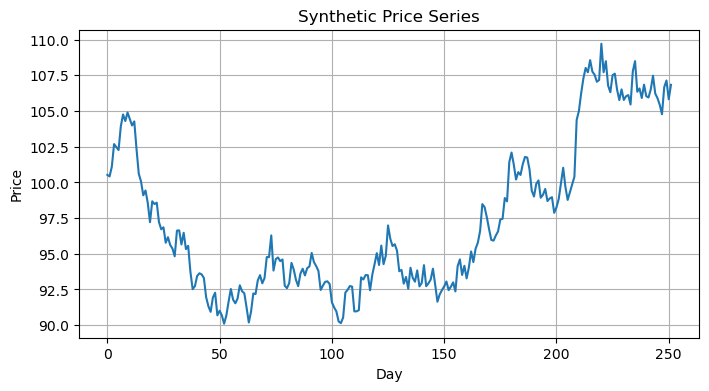

Daily volatility (std of returns): 0.0097


In [9]:
# Create synthetic price data and calculate daily returns and volatility
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # For reproducibility
n_days = 252  # 1 year of trading days
mu = 0.0003      # average daily return (0.03%)
sigma =.01 # daily volatility (1%)

# Simulate log returns
log_returns = np.random.normal(loc=mu, scale=sigma, size=n_days)

# Generate price series from log returns
price0 = 100
prices = price0 * np.exp(np.cumsum(log_returns))

plt.figure(figsize=(8,4))
plt.plot(prices)
plt.title('Synthetic Price Series')
plt.xlabel('Day')
plt.ylabel('Price')
plt.grid(True)
plt.show()

# Calculate daily returns from prices
daily_returns = np.log(prices[1:] / prices[:-1])
daily_vol = np.std(daily_returns)
print(f'Daily volatility (std of returns): {daily_vol:.4f}')

CELL 5
COMPLETE SYTHETIC BUILD

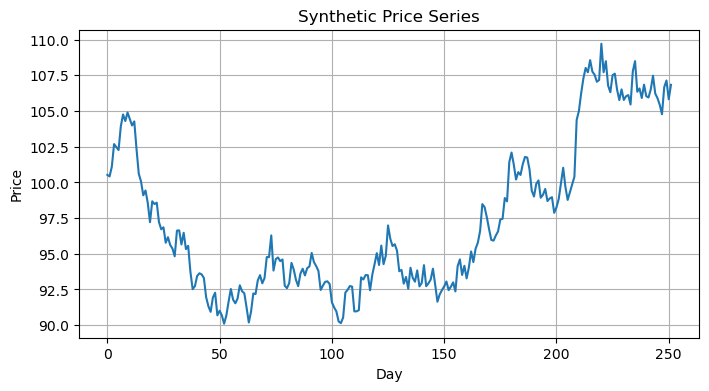

Daily volatility (std of log returns): 0.0097
Annualized volatility: 0.1532


In [10]:
# Full workflow: Simulate prices, calculate log returns, daily volatility, and annualized volatility
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_days = 252
mu = 0.0003
sigma = 0.01

# Step 1: Simulate log returns
log_returns = np.random.normal(loc=mu, scale=sigma, size=n_days)

# Step 2: Generate price series from log returns
price0 = 100
prices = price0 * np.exp(np.cumsum(log_returns))

plt.figure(figsize=(8,4))
plt.plot(prices)
plt.title('Synthetic Price Series')
plt.xlabel('Day')
plt.ylabel('Price')
plt.grid(True)
plt.show()

# Step 4: Compute daily volatility (std of log returns)
daily_vol = np.std(log_returns)
print(f'Daily volatility (std of log returns): {daily_vol:.4f}')

# Step 5: Annualize volatility
annual_vol = daily_vol * np.sqrt(252)
print(f'Annualized volatility: {annual_vol:.4f}')

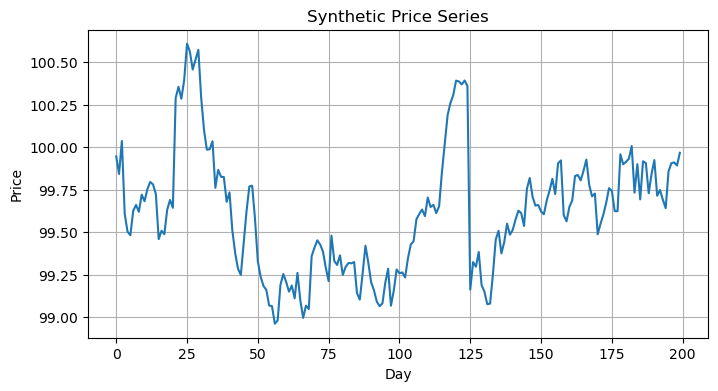

Daily volatility (std of log returns): 0.1530
Annualized volatility: 2.4292


In [23]:
# NON LOG VERSION

# Full workflow: Simulate prices, calculate log returns, daily volatility, and annualized volatility
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(44)
n_days = 200
mu = 0.0003
sigma = 0.1

# Step 1: Simulate log returns
df = 5
returns = mu + sigma * np.random.standard_t(df=df, size=n_days)
# print(f"Simulated returns: {returns}")

# Step 2: Generate price series from log returns
price0 = 100
prices = price0 + np.cumsum(returns)
# print(f"Simulated prices: {prices}")
# save prices to a DataFrame
prices_df = pd.DataFrame(prices, columns=['Close'])
# save to disk
prices_df.to_csv('../cache/synthetic_prices.csv', index=False)



plt.figure(figsize=(8,4))
plt.plot(prices)
plt.title('Synthetic Price Series')
plt.xlabel('Day')
plt.ylabel('Price')
plt.grid(True)
plt.show()

# Step 4: Compute daily volatility (std of log returns)
daily_vol = np.std(returns)
print(f'Daily volatility (std of log returns): {daily_vol:.4f}')

# Step 5: Annualize volatility
annual_vol = daily_vol * np.sqrt(252)
print(f'Annualized volatility: {annual_vol:.4f}')

rw_steps: [ 1  1 -1  1  1  1 -1  1  1 -1]


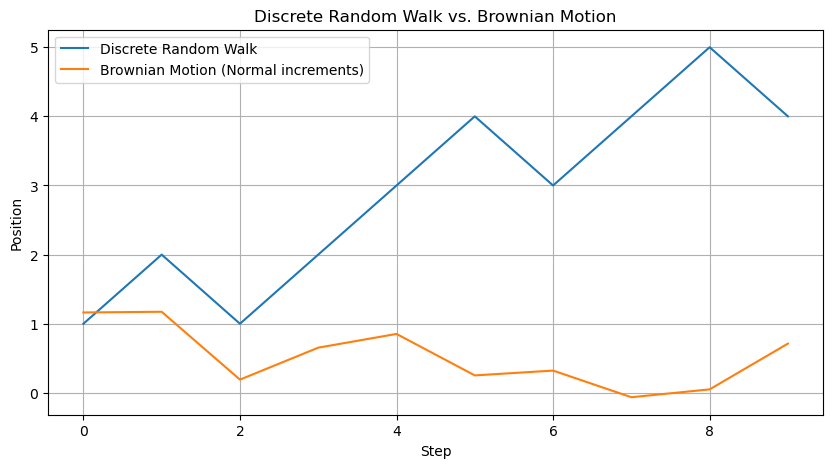

In [12]:
# Compare discrete random walk and Brownian motion (continuous limit)
import numpy as np
import matplotlib.pyplot as plt

# np.random.seed(0)
n_steps = 10
step_size = 1

# Discrete random walk: steps of +1 or -1
rw_steps = np.random.choice([-step_size, step_size], size=n_steps)
print(f'rw_steps: {rw_steps}')
rw_path = np.cumsum(rw_steps)

# Brownian motion: normal increments
bm_steps = np.random.normal(loc=0, scale=step_size, size=n_steps)
bm_path = np.cumsum(bm_steps)

plt.figure(figsize=(10,5))
plt.plot(rw_path, label='Discrete Random Walk')
plt.plot(bm_path, label='Brownian Motion (Normal increments)')
plt.title('Discrete Random Walk vs. Brownian Motion')
plt.xlabel('Step')
plt.ylabel('Position')
plt.legend()
plt.grid(True)
plt.show()

CELL 6
STUDENT_T vs NORM DIST